# P3 - Building Blocks: Shortest-Path Usage Counters

Sibling of [`p3-building-blocks.ipynb`](p3-building-blocks.ipynb), but with a
different per-timestep quantity.

Module under test: [`path_builder.py`](path_builder.py) (which reuses the
loader and trajectory code from [`adjacency_builder.py`](adjacency_builder.py)).

## Layout (same as adjacency_builder, `K = 1 + N + M`)

| index range  | role                                              |
| ------------ | ------------------------------------------------- |
| `0`          | sink                                              |
| `1 .. N`     | candidate relays (order of `problem.candidates`)  |
| `N+1 .. N+M` | mobile sensors  (order of `problem.mobile_nodes`) |

## Per-timestep semantics

For each timestep `t`:

1. build the radius-of-reach adjacency `A(t)` (as in `adjacency_builder`);
2. run a BFS from the **sink** in `A(t)` to obtain a shortest-hop tree;
3. for each mobile `m`, trace the BFS shortest path back to the sink;
4. **increment by 1 every node on that path** (and every edge it uses).

Outputs per timestep:

* `node_count(t)` — `(K,)` int: `node_count(t)[u]` = #(mobiles whose shortest path uses node `u`)
* `edge_count(t)` — `(K, K)` uint16: `edge_count(t)[u, v]` = #(mobiles whose shortest path uses edge `(u, v)`)

Accumulated over the simulation horizon (`T` timesteps, `M` mobiles):

$$\text{node\_accumulated}[u] = \sum_t \text{node\_count}(t)[u] \le T \cdot M$$

$$\text{edge\_accumulated}[u, v] = \sum_t \text{edge\_count}(t)[u, v] \le T \cdot M$$

## Load an instance and run the pipeline

In [10]:
import importlib
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Patch

import adjacency_builder as ab
import path_builder as pb
importlib.reload(ab)
importlib.reload(pb)

INSTANCE_PATH = "pop-estimator/examples/ind2.json"

instance = ab.load_instance(INSTANCE_PATH)
result   = pb.build_from_instance(instance)
summary  = pb.summarise(result, instance)
pb.print_summary(summary)

Instance:           C:\Users\jcf_s\source\git\simlab-algorithms\pop-estimator\examples\ind2.json
Radius of reach:    50.0
Timesteps (T):      181
Nodes (K=1+N+M):    69  (N=64, M=4)
Raw step counts:    [181, 90, 48, 120]  (T = max)
Upper bound:        T*M = 724  (per node and per edge)
Per-node accumulated stats:
  min=0, max=724, mean=45.83, sum=3162
Per-edge accumulated stats:
  min=0, max=323, mean=1.024, sum=4876, density=3.32%
Node score by role:
  sink       min= 724 max= 724 mean= 724.00 nonzero=1
  candidates min=   0 max= 323 mean=  26.58 nonzero=34
  mobiles    min= 181 max= 189 mean= 184.25 nonzero=4
Mobiles connected to sink per timestep:
  min=4, max=4, mean=4.00
  full connectivity = 100.0% of t,  no connectivity = 0.0% of t


## Inspect the tensors

Primary output: `node_accumulated` (length `K`). The per-edge matrix is kept
for matrix-style visualisations.

In [11]:
positions        = result["positions"]          # (T, K, 2)
node_per_t       = result["node_per_t"]         # (T, K),    int64
edge_per_t       = result["edge_per_t"]         # (T, K, K), uint16
node_accumulated = result["node_accumulated"]   # (K,),      int64
edge_accumulated = result["edge_accumulated"]   # (K, K),    int64
n_active_per_t   = result["n_active_per_t"]     # (T,),      int64
layout           = result["layout"]
R                = result["radius"]

T, K = node_per_t.shape
N, M = layout.N, layout.M
s_idx = layout.sink_index
c_idx = np.asarray(layout.candidate_indices)
m_idx = np.asarray(layout.mobile_indices)
TM    = T * M

print(f"node_per_t:       shape={node_per_t.shape}, dtype={node_per_t.dtype}, max={int(node_per_t.max())}")
print(f"edge_per_t:       shape={edge_per_t.shape}, dtype={edge_per_t.dtype}, max={int(edge_per_t.max())}")
print(f"node_accumulated: shape={node_accumulated.shape}, max={int(node_accumulated.max())}")
print(f"edge_accumulated: shape={edge_accumulated.shape}, max={int(edge_accumulated.max())}")
print(f"upper bound per node/edge = T*M = {TM}")

# Sanity
assert int(node_per_t.max()) <= M, "per-t node count bounded by M"
assert int(edge_per_t.max()) <= M, "per-t edge count bounded by M"
assert np.array_equal(edge_per_t, edge_per_t.transpose(0, 2, 1)), "edge tensor symmetric per t"
assert (edge_per_t.diagonal(axis1=1, axis2=2) == 0).all(), "zero diagonal"
assert int(node_accumulated.max()) <= TM
assert int(edge_accumulated.max()) <= TM

node_per_t:       shape=(181, 69), dtype=int64, max=4
edge_per_t:       shape=(181, 69, 69), dtype=uint16, max=2
node_accumulated: shape=(69,), max=724
edge_accumulated: shape=(69, 69), max=323
upper bound per node/edge = T*M = 724


## Heatmap of the accumulated edge-usage matrix

Bright cells are edges that frequently appear on shortest mobile-to-sink
paths over the simulation. Note that this is typically much sparser than
the adjacency heatmap, because only edges actually used by some shortest
path get any score at all.

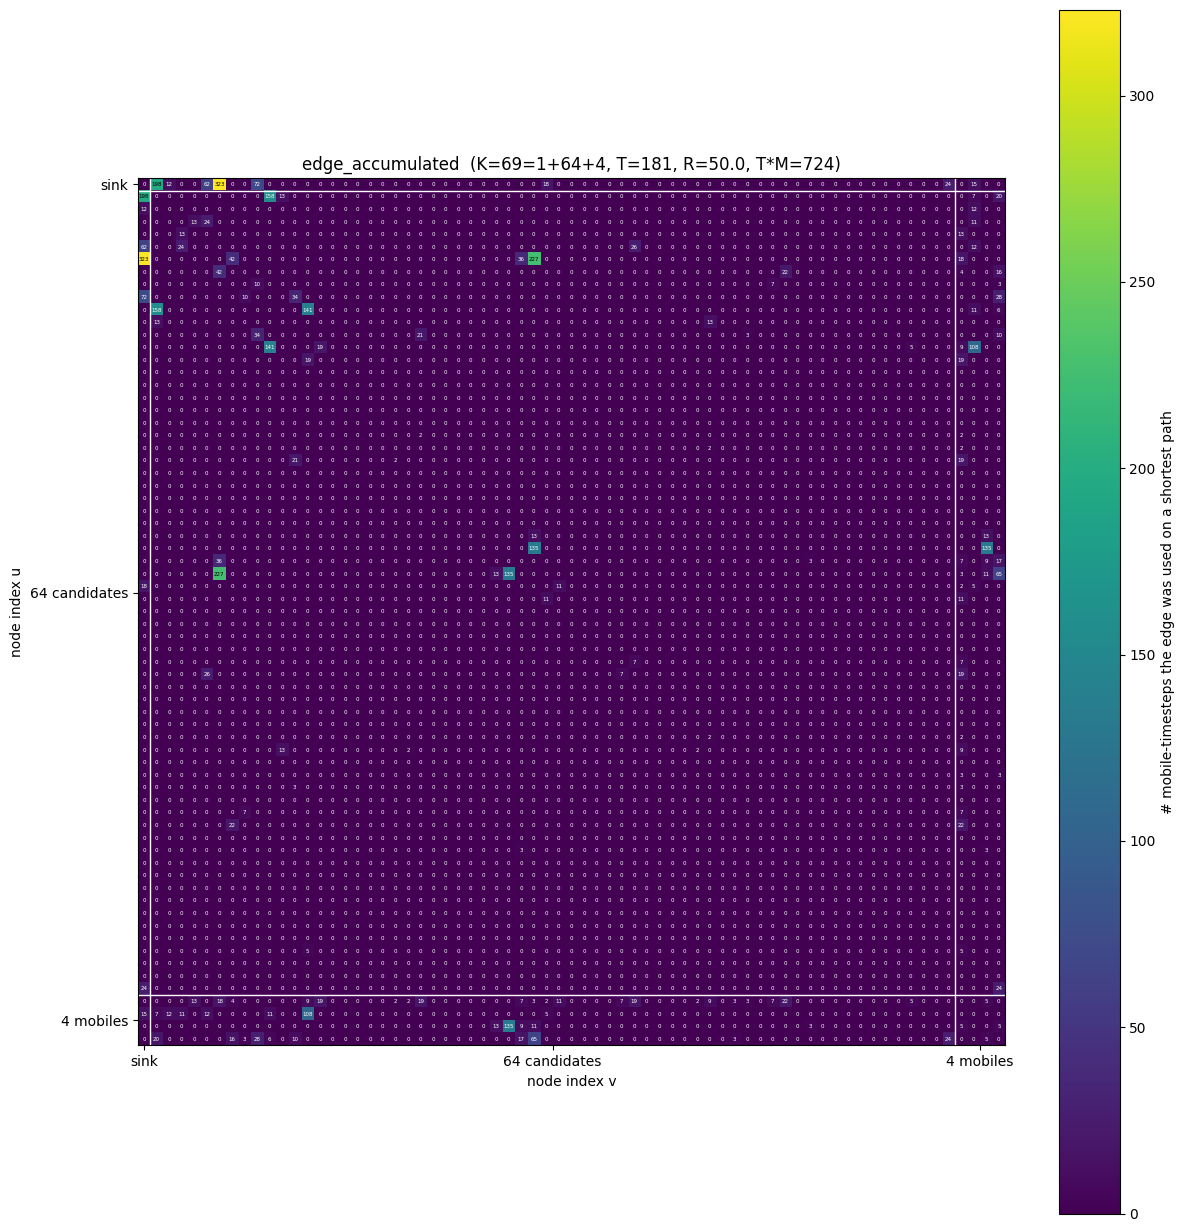

In [12]:
fig, ax = plt.subplots(figsize=(max(8.5, 0.18 * K), max(7.5, 0.18 * K)))
im = ax.imshow(edge_accumulated, cmap="viridis")
ax.set_xlabel("node index v")
ax.set_ylabel("node index u")
ax.set_title(
    f"edge_accumulated  (K={K}=1+{N}+{M}, T={T}, R={R}, T*M={TM})"
)

vmax = max(int(edge_accumulated.max()), 1)
threshold = vmax * 0.55
font_size = max(4, min(9, int(160 / K)))
for u in range(K):
    for v in range(K):
        val = int(edge_accumulated[u, v])
        ax.text(v, u, str(val),
                ha="center", va="center",
                fontsize=font_size,
                color="white" if val < threshold else "black")

for split in (0.5, 0.5 + N):
    ax.axhline(split, color="white", linewidth=1.0)
    ax.axvline(split, color="white", linewidth=1.0)
centres = [0, 0.5 + N / 2.0, 0.5 + N + M / 2.0]
ax.set_xticks(centres); ax.set_xticklabels(["sink", f"{N} candidates", f"{M} mobiles"])
ax.set_yticks(centres); ax.set_yticklabels(["sink", f"{N} candidates", f"{M} mobiles"])
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("# mobile-timesteps the edge was used on a shortest path")
plt.tight_layout()
plt.show()

## Per-timestep connectivity and total path length

Top: number of mobiles connected to the sink at each timestep.

Bottom: total path length (in nodes) summed over all mobile-paths at each
timestep. With `M_active(t)` mobiles connected, this equals
`sum over m of (hop_count(m, sink) + 1)`.

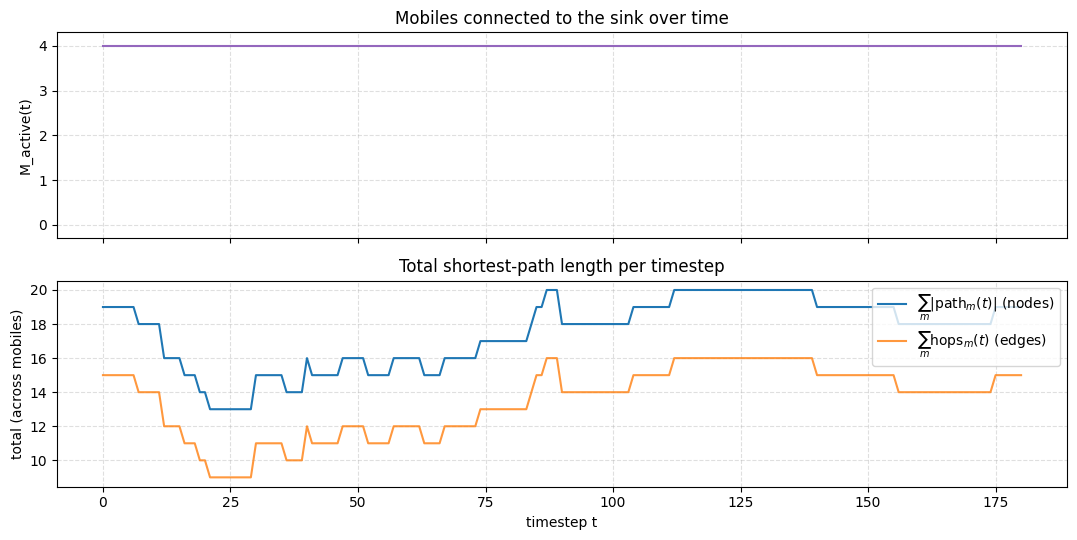

In [13]:
total_path_nodes_t = node_per_t.sum(axis=1)            # (T,)
total_path_edges_t = edge_per_t.sum(axis=(1, 2)) // 2  # symmetric -> divide by 2

fig, (ax_n, ax_l) = plt.subplots(2, 1, figsize=(11, 5.5), sharex=True)
ax_n.step(np.arange(T), n_active_per_t, where="mid", color="tab:purple")
ax_n.set_ylim(-0.3, M + 0.3)
ax_n.set_yticks(range(0, M + 1))
ax_n.set_ylabel("M_active(t)")
ax_n.set_title("Mobiles connected to the sink over time")
ax_n.grid(True, linestyle="--", alpha=0.4)

ax_l.plot(total_path_nodes_t, label="$\\sum_m |\\mathrm{path}_m(t)|$ (nodes)",
          color="tab:blue")
ax_l.plot(total_path_edges_t, label="$\\sum_m \\mathrm{hops}_m(t)$ (edges)",
          color="tab:orange", alpha=0.8)
ax_l.set_ylabel("total (across mobiles)")
ax_l.set_xlabel("timestep t")
ax_l.set_title("Total shortest-path length per timestep")
ax_l.grid(True, linestyle="--", alpha=0.4)
ax_l.legend(loc="upper right")
plt.tight_layout()
plt.show()

## Spatial snapshot at a chosen timestep

Edges actually used by some mobile's shortest path are drawn in green;
node labels show the per-node hit count at this timestep. Mobiles without
a path appear unconnected.

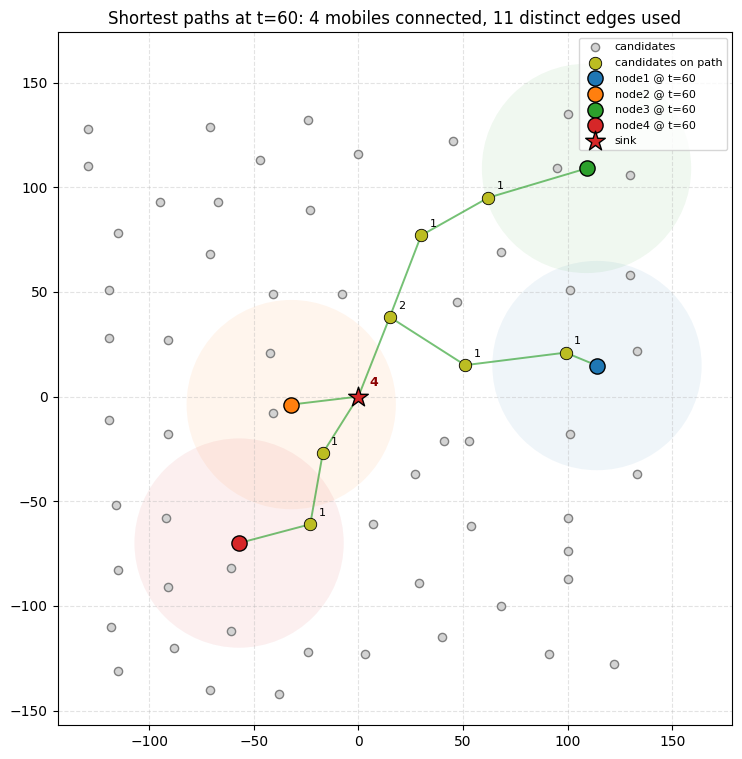

In [14]:
t_snapshot = T // 3
E_t  = edge_per_t[t_snapshot]              # (K, K)
Nc_t = node_per_t[t_snapshot]              # (K,)
P_t  = positions[t_snapshot]               # (K, 2)

fig, ax = plt.subplots(figsize=(9, 9))
us, vs = np.where(np.triu(E_t, k=1))
for u, v in zip(us, vs):
    ax.plot([P_t[u, 0], P_t[v, 0]], [P_t[u, 1], P_t[v, 1]],
            color="tab:green", alpha=0.65, linewidth=1.4, zorder=2)
# All candidates (faint background)
Q = P_t[c_idx]
ax.scatter(Q[:, 0], Q[:, 1], s=35, color="lightgray", edgecolor="gray",
           label="candidates", zorder=2)
# Candidates with non-zero hit at this t -> larger and labelled
hit_cand = c_idx[Nc_t[c_idx] > 0]
if hit_cand.size:
    ax.scatter(P_t[hit_cand, 0], P_t[hit_cand, 1], s=80,
               color="tab:olive", edgecolor="black", linewidth=0.6,
               label="candidates on path", zorder=3)
    for j in hit_cand:
        ax.annotate(str(int(Nc_t[j])), xy=(P_t[j, 0], P_t[j, 1]),
                    xytext=(6, 6), textcoords="offset points", fontsize=8)
# Mobiles
for i, mi in enumerate(m_idx):
    mx, my = P_t[mi]
    ax.add_patch(Circle((mx, my), R, alpha=0.07, color=f"C{i}", linewidth=0))
    ax.scatter([mx], [my], s=120, color=f"C{i}", edgecolor="black",
               label=f"{instance.mobile_nodes[i].name} @ t={t_snapshot}", zorder=4)
# Sink
sx, sy = P_t[s_idx]
ax.scatter([sx], [sy], s=220, marker="*", color="tab:red",
           edgecolor="black", label="sink", zorder=5)
ax.annotate(str(int(Nc_t[s_idx])), xy=(sx, sy),
            xytext=(8, 8), textcoords="offset points",
            fontsize=9, color="darkred", weight="bold")
ax.set_aspect("equal")
ax.grid(True, linestyle="--", alpha=0.35)
ax.set_title(
    f"Shortest paths at t={t_snapshot}: "
    f"{int(n_active_per_t[t_snapshot])} mobiles connected, "
    f"{len(us)} distinct edges used"
)
ax.legend(loc="upper right", fontsize=8)
plt.show()

## Per-fixed-node score (sorted bar chart)

$$\text{score}(u) = \text{node\_accumulated}[u] = \sum_t \#\{ m : u \in \text{path}_m(t) \}$$

Interpretation: total mobile-timesteps the node was on a shortest mobile-to-sink
path. Upper bound `T * M` (always on every mobile's path).

Upper bound = T*M = 724
Score range = [0, 724]
Fixed nodes with score 0 (never on any shortest path): 30 / 65


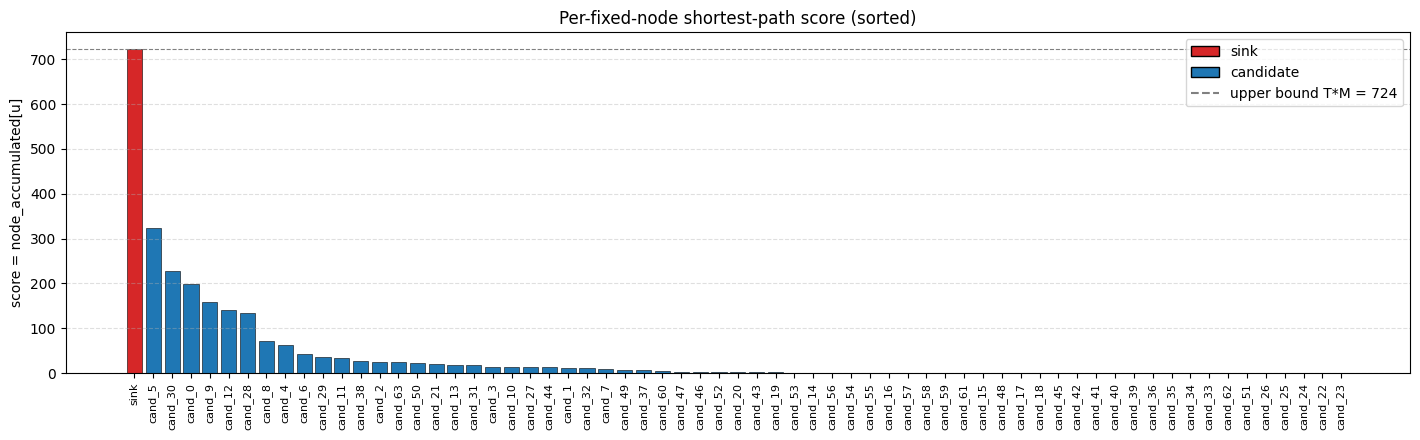

In [15]:
fixed_idx   = np.r_[s_idx, c_idx]
fixed_names = [layout.names[i] for i in fixed_idx]
scores      = node_accumulated[fixed_idx]                 # length 1+N

order         = np.argsort(scores)[::-1]
sorted_scores = scores[order]
sorted_names  = [fixed_names[i] for i in order]
sorted_kind   = ["sink" if fixed_idx[i] == s_idx else "candidate" for i in order]
colors        = ["tab:red" if k == "sink" else "tab:blue" for k in sorted_kind]

print(f"Upper bound = T*M = {TM}")
print(f"Score range = [{int(scores.min())}, {int(scores.max())}]")
n_zero = int((scores == 0).sum())
print(f"Fixed nodes with score 0 (never on any shortest path): {n_zero} / {len(scores)}")

fig, ax = plt.subplots(figsize=(max(9, 0.22 * len(scores)), 4.5))
ax.bar(range(len(scores)), sorted_scores, color=colors, edgecolor="black", linewidth=0.4)
ax.set_xticks(range(len(scores)))
ax.set_xticklabels(sorted_names, rotation=90, fontsize=8)
ax.axhline(TM, color="gray", linestyle="--", linewidth=0.8,
           label=f"upper bound T*M = {TM}")
ax.set_ylabel("score = node_accumulated[u]")
ax.set_title("Per-fixed-node shortest-path score (sorted)")
ax.legend(handles=[
    Patch(facecolor="tab:red",  edgecolor="black", label="sink"),
    Patch(facecolor="tab:blue", edgecolor="black", label="candidate"),
    plt.Line2D([0], [0], color="gray", linestyle="--", label=f"upper bound T*M = {TM}"),
], loc="upper right")
ax.grid(True, axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

## Spatial heat-graph of fixed nodes

Same idea as in the adjacency notebook (temperature colormap + numeric
labels), now driven by the shortest-path score. Light grey edges are
candidate-candidate edges that were ever used by some shortest path
(`edge_accumulated[u, v] > 0`).

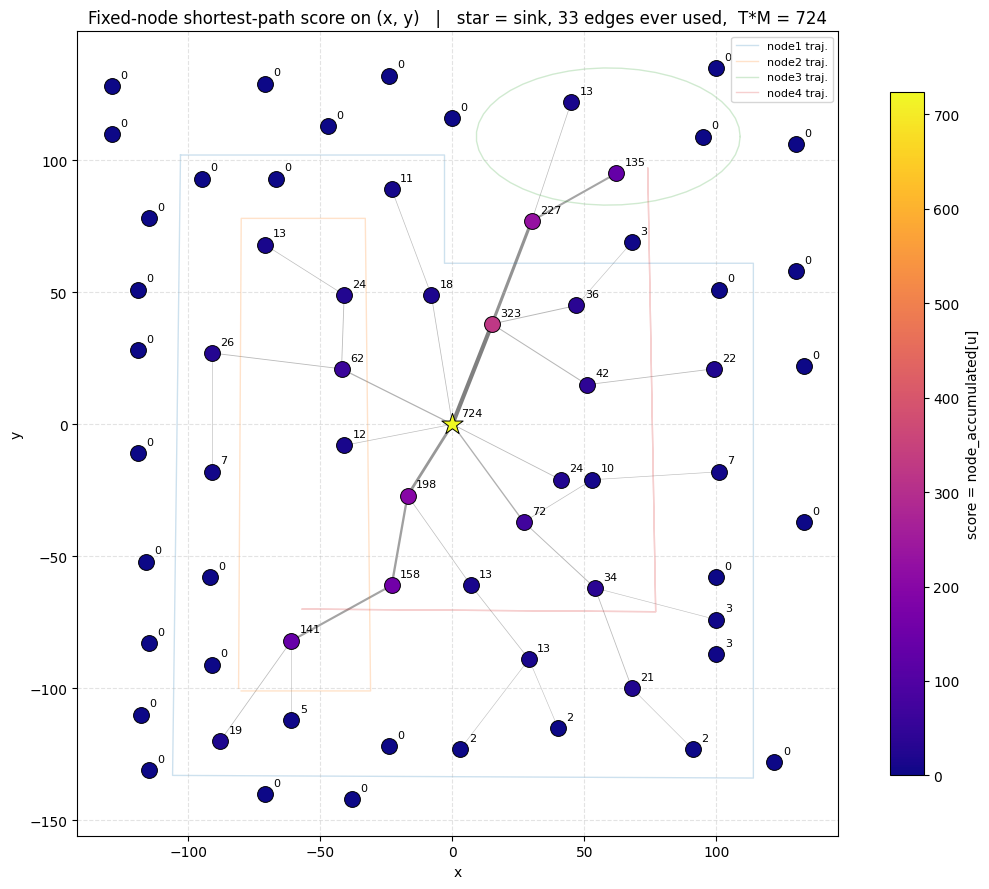

In [16]:
CMAP_NAME = "plasma"  # try "hot", "inferno", "coolwarm", "viridis", "magma"

fixed_xy  = positions[0, fixed_idx]
score_max = max(int(scores.max()), 1)
cmap      = plt.get_cmap(CMAP_NAME)
norm      = plt.Normalize(vmin=0, vmax=score_max)

# Edges actually used on some shortest path, between fixed nodes
fixed_edge_block = edge_accumulated[np.ix_(fixed_idx, fixed_idx)]
edge_us, edge_vs = np.where(np.triu(fixed_edge_block > 0, k=1))
edge_w_max = max(int(fixed_edge_block.max()), 1)

fig, ax = plt.subplots(figsize=(11, 9))
# Edges with width proportional to usage frequency
for u, v in zip(edge_us, edge_vs):
    w = float(fixed_edge_block[u, v]) / edge_w_max
    ax.plot([fixed_xy[u, 0], fixed_xy[v, 0]],
            [fixed_xy[u, 1], fixed_xy[v, 1]],
            color="gray", linewidth=0.4 + 2.6 * w, alpha=0.5 + 0.5 * w, zorder=1)
# Mobile trajectories in the background
for i in range(M):
    traj = positions[:, m_idx[i], :]
    ax.plot(traj[:, 0], traj[:, 1], color=f"C{i}", alpha=0.22,
            linewidth=1.0, zorder=1, label=f"{instance.mobile_nodes[i].name} traj.")
# Fixed nodes coloured by score, with numeric labels
for k, gi in enumerate(fixed_idx):
    x, y = fixed_xy[k]
    s = int(scores[k])
    is_sink = (gi == s_idx)
    ax.scatter([x], [y],
               s=260 if is_sink else 130,
               marker="*" if is_sink else "o",
               c=[cmap(norm(s))],
               edgecolor="black", linewidth=0.7, zorder=3)
    ax.annotate(str(s), xy=(x, y), xytext=(6, 6),
                textcoords="offset points", fontsize=8,
                color="black", zorder=4)
ax.set_aspect("equal")
ax.grid(True, linestyle="--", alpha=0.35)
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title(
    f"Fixed-node shortest-path score on (x, y)   |   star = sink, "
    f"{len(edge_us)} edges ever used,  T*M = {TM}"
)
ax.legend(loc="upper right", fontsize=8)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=0.85)
cbar.set_label("score = node_accumulated[u]")
plt.tight_layout()
plt.show()

## Persist the result to disk (optional)

File names are prefixed with `path_` to avoid collisions with the
adjacency module.

In [17]:
# Uncomment to export:
# written = pb.export_results(
#     "pop-estimator/results/p3_path_demo",
#     result, summary, force=True,
# )
# for k, p in written.items():
#     print(f"{k:12s} -> {p}")